### Indexing: Text Embedding with OpenAI ###

###### Setup API Key som miljøvariabel ######

In [ ]:
%load_ext dotenv
%dotenv ../.env

###### Import ######

In [17]:
from langchain_community.document_loaders import Docx2txtLoader
from langchain_text_splitters.markdown import MarkdownHeaderTextSplitter
from langchain_text_splitters.character import CharacterTextSplitter
from langchain_openai.embeddings import OpenAIEmbeddings
import numpy as np

###### doc2txt instans med doc filnavn som argument ######

In [6]:
loader_docx = Docx2txtLoader("Introduction_to_Data_and_Data_Science_2.docx")
pages = loader_docx.load()

###### Opret markdown header splitter objekt

In [7]:
md_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "Course Title"),
                         ("##","Lecture Title")])

###### Objekt der opbevare markdown splittede dokumenter ######

In [8]:
pages_md_split = md_splitter.split_text(pages[0].page_content)

###### Fjerner newline characters fra markdown splittede dokumenter ######

In [9]:
for i in range(len(pages_md_split)):
    pages_md_split[i].page_content = ' '.join(pages_md_split[i].page_content.split())

###### Opret character text splitter objekt & split dokumentet ######

In [10]:
char_splitter = CharacterTextSplitter(
    separator=".",
    chunk_size=500,
    chunk_overlap=50
)

In [11]:
pages_char_split = char_splitter.split_documents(pages_md_split)

###### Opret OpenAI Embeddings instans og angiv hvilken model der skal bruges ######
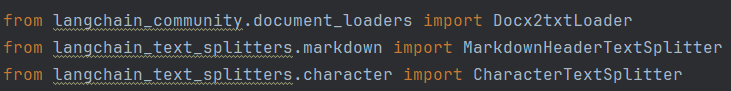

In [13]:
embedding = OpenAIEmbeddings(model="text-embedding-ada-002")

In [14]:
vector1 = embedding.embed_query(pages_char_split[3].page_content)
vector2 = embedding.embed_query(pages_char_split[5].page_content)
vector3 = embedding.embed_query(pages_char_split[18].page_content)

In [16]:
# Længderne på vektorne
len(vector1), len(vector2), len(vector3)

(1536, 1536, 1536)

In [21]:
# dot product mellem vektorerne
np.dot(vector1, vector2), np.dot(vector1, vector3), np.dot(vector2, vector3)

(0.8791284497943928, 0.8000235828747095, 0.7934993700101874)

###### beregn magnituden af vektorerne ######

In [22]:
np.linalg.norm(vector1), np.linalg.norm(vector2), np.linalg.norm(vector3)

(0.999999951896922, 0.9999999432048748, 0.9999999688261214)